# Четвёртая лабораторная работа
## Кластерный анализ
## Цель задания
Изучить основные методы кластеризации в машинном обучении, освоить практические навыки
построения, обучения и анализа моделей кластеризации для решения задач группировки данных без
учителя.
Научиться интерпретировать результаты кластеризации и оценивать их качество.

## Выполнение

### 1. Выбор датасета
Выберите датасет на сайте kaggle.com или используйте набор данных из предыдущих лабораторных
работ, если его можно адаптировать к задаче кластеризации. Для этого необходимо исключить
целевую переменную и рассматривать данные как неразмеченные. Однако эту переменную нужно
сохранить отдельно для последующей валидации результатов (расчет ARI, NMI). 
    
https://www.kaggle.com/datasets/pranavkapratwar/fruit-classification



## 2. Предобработка данных

### Импорты

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram


### Анализ пропущенных значение и их обработка

In [146]:
dataset = pd.read_csv("./data/fruit_classification_dataset.csv")

def process_null_val():
    null_val_count = dataset.isnull().sum()

    print("Количество пропусков")
    print(null_val_count)

    if len(null_val_count) > 0:
        return dataset.dropna()
    else:
        return dataset


def process_duplicate_rows(df, target_col='fruit_name'):
    feature_cols = [c for c in df.columns if c != target_col]
    df_clean = df.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
    print("До:", len(df), "После:", len(df_clean), "удалено:", len(df)-len(df_clean))
    return df_clean
    
process_null_val()
dataset = process_duplicate_rows(dataset)

Количество пропусков
size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64
До: 10000 После: 9754 удалено: 246


### Обработка выбросов


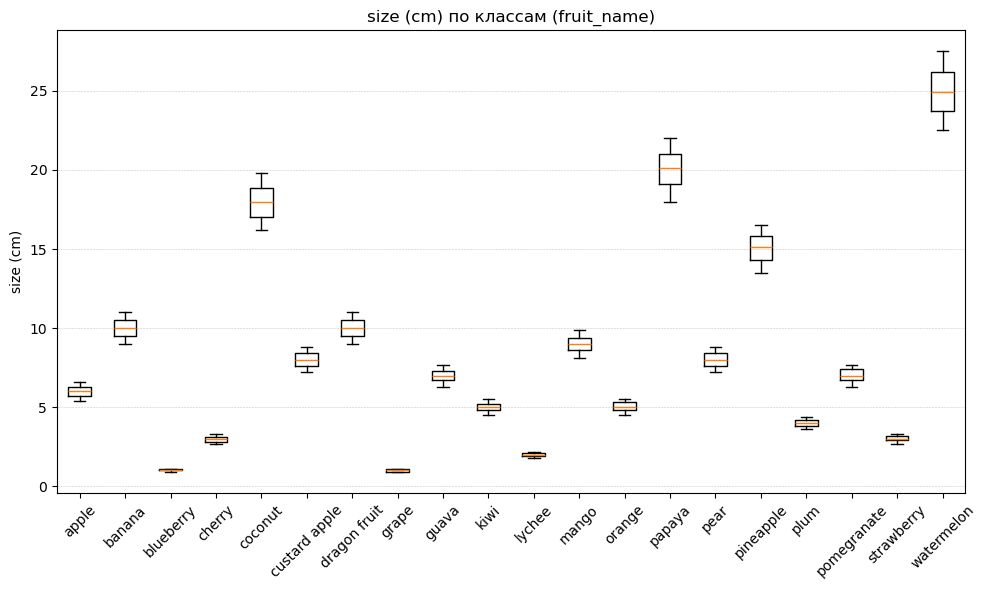

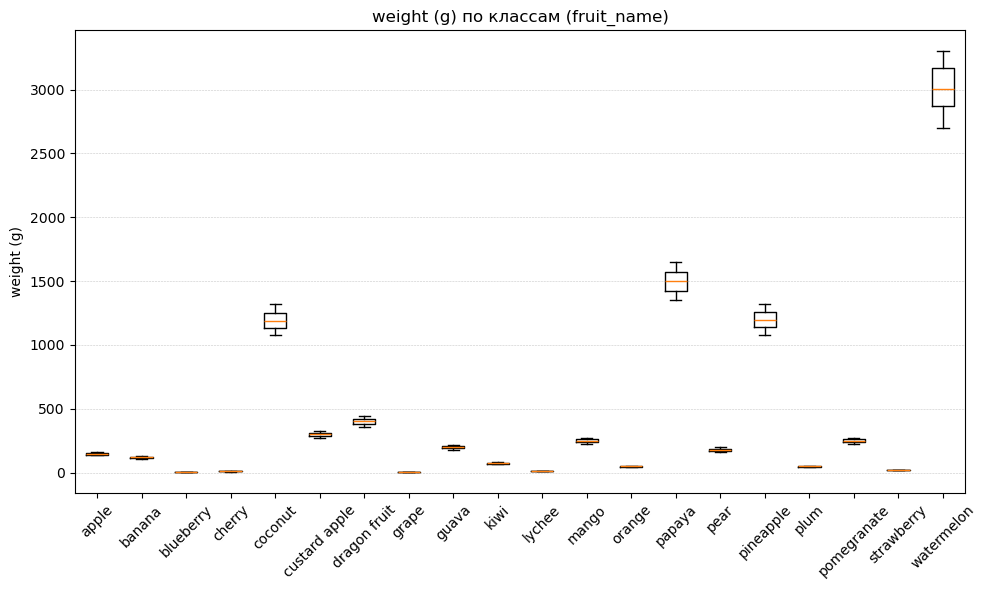

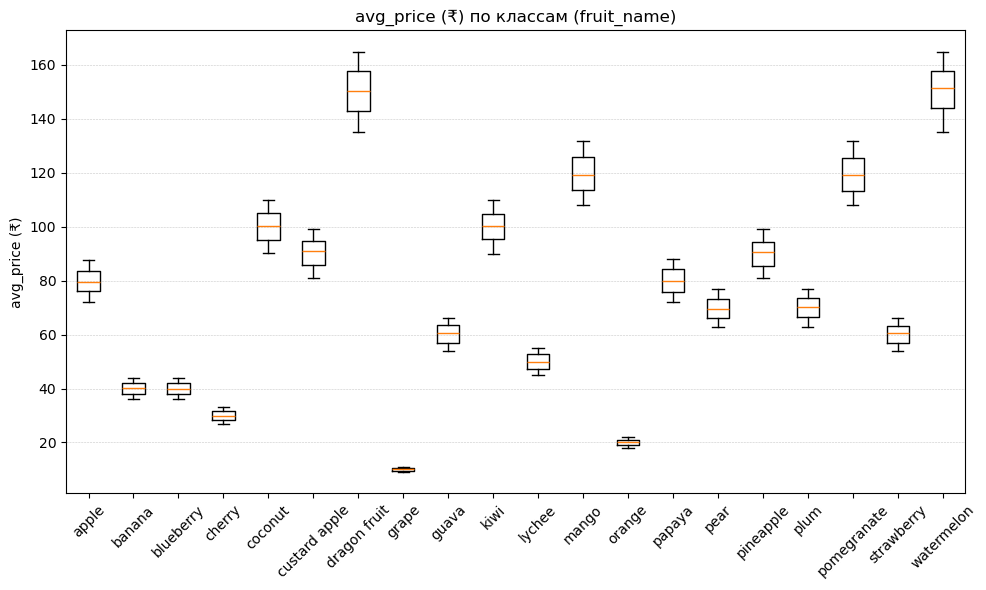

Class="apple": удалено 0 строк, осталось 492
Class="banana": удалено 0 строк, осталось 502
Class="blueberry": удалено 0 строк, осталось 443
Class="cherry": удалено 0 строк, осталось 462
Class="coconut": удалено 0 строк, осталось 502
Class="custard apple": удалено 0 строк, осталось 516
Class="dragon fruit": удалено 0 строк, осталось 496
Class="grape": удалено 0 строк, осталось 346
Class="guava": удалено 0 строк, осталось 481
Class="kiwi": удалено 0 строк, осталось 506
Class="lychee": удалено 0 строк, осталось 495
Class="mango": удалено 0 строк, осталось 500
Class="orange": удалено 0 строк, осталось 484
Class="papaya": удалено 0 строк, осталось 509
Class="pear": удалено 0 строк, осталось 534
Class="pineapple": удалено 0 строк, осталось 533
Class="plum": удалено 0 строк, осталось 489
Class="pomegranate": удалено 0 строк, осталось 534
Class="strawberry": удалено 0 строк, осталось 432
Class="watermelon": удалено 0 строк, осталось 498
Итого: до = 9754 строк, после = 9754 строк, удалено = 0


In [147]:
def make_exhaust_boxplots(df, cols=None, class_col='fruit_name', per_class=True, figsize=(10,6), showfliers=True):
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if class_col in cols:
        cols = [c for c in cols if c != class_col]

    if per_class and class_col in df.columns:
        classes = sorted(df[class_col].dropna().unique().tolist())
        for col in cols:
            data = []
            labels = []
            for cls in classes:
                arr = df.loc[df[class_col] == cls, col].dropna().values
                if arr.size > 0:
                    data.append(arr)
                    labels.append(cls)
            if not data:
                continue
            plt.figure(figsize=figsize)
            plt.boxplot(data, showfliers=showfliers)
            plt.title(f'{col} по классам ({class_col})')
            plt.ylabel(col)
            plt.xticks(ticks=range(1, len(labels)+1), labels=labels, rotation=45)
            plt.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.7)
            plt.tight_layout()
            plt.show()
    else:
        for col in cols:
            arr = df[col].dropna().values
            if arr.size == 0:
                continue
            plt.figure(figsize=figsize)
            plt.boxplot(arr, showfliers=showfliers)
            plt.title(col)
            plt.ylabel(col)
            plt.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.7)
            plt.tight_layout()
            plt.show()


def per_class_outlier_report(df, cols=None, class_col='fruit_name', iqr_multiplier=1.5, min_samples=5):
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if class_col in cols:
        cols = [c for c in cols if c != class_col]

    rows = []
    for cls in sorted(df[class_col].dropna().unique()):
        cls_df = df[df[class_col] == cls]
        n = len(cls_df)
        for col in cols:
            series = cls_df[col].dropna()
            if series.empty:
                rows.append((cls, col, n, np.nan, np.nan, np.nan, np.nan, np.nan))
                continue
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - iqr_multiplier * IQR
            upper = Q3 + iqr_multiplier * IQR
            out_count = int(((series < lower) | (series > upper)).sum())
            rows.append((cls, col, n, float(Q1), float(Q3), float(IQR), float(lower), float(upper), out_count))
    report = pd.DataFrame(rows, columns=[class_col, 'column', 'n_samples', 'Q1', 'Q3', 'IQR', 'lower', 'upper', 'outliers'])
    return report


def exhaust_process(df,
                    cols=None,
                    class_col='fruit_name',
                    method='iqr',            
                    iqr_multiplier=1.5,
                    min_samples=15,
                    contamination=0.02,       
                    sequential_within_class=True,
                    verbose=True):

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if class_col in cols:
        cols = [c for c in cols if c != class_col]

    usable_cols = []
    for c in cols:
        if c not in df.columns:
            continue
        uniq = df[c].dropna().unique()
        if len(uniq) <= 1:
            if verbose:
                print(f'Колонка "{c}" пропущена (<=1 уникальное значение).')
            continue
        usable_cols.append(c)
    cols = usable_cols
    if not cols:
        if verbose:
            print("Нет числовых колонок для фильтрации.")
        return df.copy(), pd.DataFrame(columns=[class_col, 'removed', 'remaining'])

    df_filtered = df.copy()
    report_rows = []

    classes = sorted(df[class_col].dropna().unique().tolist())
    for cls in classes:
        idx_cls = df_filtered[df_filtered[class_col] == cls].index
        n_before = len(idx_cls)
        if n_before == 0:
            report_rows.append((cls, 0, 0))
            continue
        if n_before < min_samples:
            if verbose:
                print(f'Class="{cls}": мало примеров ({n_before}<{min_samples}), пропускаю per-class фильтрацию.')
            report_rows.append((cls, 0, n_before))
            continue

        to_drop = pd.Index([])

        if method in ('iqr', 'combined'):
            if sequential_within_class:
                keep = pd.Series(True, index=idx_cls)
                for col in cols:
                    series = df_filtered.loc[keep[keep].index, col].dropna()
                    if series.empty:
                        continue
                    Q1 = series.quantile(0.25)
                    Q3 = series.quantile(0.75)
                    IQR = Q3 - Q1
                    lower = Q1 - iqr_multiplier * IQR
                    upper = Q3 + iqr_multiplier * IQR
                    idx_current = keep[keep].index
                    mask_col = (df_filtered.loc[idx_current, col] >= lower) & (df_filtered.loc[idx_current, col] <= upper)
                    drop_idx = idx_current[~mask_col]
                    if drop_idx.size:
                        keep.loc[drop_idx] = False
                to_drop = to_drop.union(keep[~keep].index)
            else:
                masks = []
                for col in cols:
                    series = df_filtered.loc[idx_cls, col].dropna()
                    if series.empty:
                        masks.append(pd.Series(True, index=idx_cls))
                        continue
                    Q1 = series.quantile(0.25)
                    Q3 = series.quantile(0.75)
                    IQR = Q3 - Q1
                    lower = Q1 - iqr_multiplier * IQR
                    upper = Q3 + iqr_multiplier * IQR
                    masks.append((df_filtered.loc[idx_cls, col] >= lower) & (df_filtered.loc[idx_cls, col] <= upper))
                if masks:
                    combined = np.logical_and.reduce([m.reindex(idx_cls, fill_value=True) for m in masks])
                    to_drop = to_drop.union(idx_cls.difference(idx_cls[combined]))

        if method in ('isolation_forest', 'combined'):
            remaining_idx = idx_cls.difference(to_drop)
            if len(remaining_idx) >= max(min_samples, 10):
                X = df_filtered.loc[remaining_idx, cols].fillna(df_filtered.loc[remaining_idx, cols].median())
                scaler = StandardScaler()
                Xs = scaler.fit_transform(X)
                iso = IsolationForest(contamination=contamination, random_state=42)
                preds = iso.fit_predict(Xs)
                drop_iso = remaining_idx[preds == -1]
                to_drop = to_drop.union(drop_iso)

        removed = len(to_drop)
        if removed > 0:
            df_filtered = df_filtered.drop(index=to_drop)
        report_rows.append((cls, int(removed), int(df_filtered[df_filtered[class_col] == cls].shape[0])))
        if verbose:
            print(f'Class="{cls}": удалено {removed} строк, осталось {df_filtered[df_filtered[class_col]==cls].shape[0]}')

    report = pd.DataFrame(report_rows, columns=[class_col, 'removed', 'remaining'])
    if verbose:
        total_before = df.shape[0]
        total_after = df_filtered.shape[0]
        print(f'Итого: до = {total_before} строк, после = {total_after} строк, удалено = {total_before - total_after}')
    return df_filtered, report

make_exhaust_boxplots(dataset, per_class=True) 

dataset = exhaust_process(dataset,
                                cols=['size (cm)','weight (g)','avg_price (₹)'],
                                class_col='fruit_name',
                                iqr_multiplier=1.5,
                                min_samples=20,
                                sequential_within_class=True,
                                verbose=True)[0]


### Обработка типов данных

In [148]:
def to_float(series, params=None, return_params=False):
    s = pd.Series(series)
    s = s.astype(str).str.strip()
    s = s.str.replace(',', '.', regex=False)
    s = s.str.replace(r'[^\d\.\-]', '', regex=True)
    s = s.replace('', np.nan)
    s = pd.to_numeric(s, errors='coerce').astype('float')

    if params is None:
        mean = s.mean(skipna=True)
        std = s.std(skipna=True)
        if pd.isna(std) or std == 0:
            std = 1.0
        params = {'mean': float(mean) if not pd.isna(mean) else 0.0, 'std': float(std)}
    mean = params.get('mean', 0.0)
    std = params.get('std', 1.0)
    if std == 0:
        std = 1.0
    s_norm = (s - mean) / std

    if return_params:
        return s_norm, params
    return s_norm

def to_str(series):
    return series.where(series.isna(), series.astype(str).str.strip())

def one_hot_fruit(df, class_col='fruit_name', top_k=None, keep_original=False, prefix='fruit'):
    if class_col not in df.columns:
        return df.copy()
    s = df[class_col].astype(str).str.strip()
    if top_k is not None:
        top = s.value_counts().index[:top_k]
        s = s.where(s.isin(top), other='other')
    dummies = pd.get_dummies(s, prefix=prefix)
    out = pd.concat([df.copy(), dummies], axis=1)
    if not keep_original:
        out = out.drop(columns=[class_col])
    return out

def transform_dataset(df,
                      float_cols=('size (cm)', 'weight (g)', 'avg_price (₹)'),
                      str_cols=('shape', 'color', 'taste'),
                      class_col='fruit_name',
                      top_k_fruits=None,
                      keep_original_class=False,
                      prefix='fruit',
                      categorical_encoding='onehot'):

    df = df.copy()
    norm_params = {}
    for c in float_cols:
        if c in df.columns:
            df[c], params = to_float(df[c], params=None, return_params=True)
            norm_params[c] = params

    if categorical_encoding == 'onehot':
        for c in str_cols:
            if c in df.columns:
                s = to_str(df[c]).replace({'nan': np.nan})
                dummies = pd.get_dummies(s, prefix=c, dummy_na=True)
                df = pd.concat([df.drop(columns=[c]), dummies], axis=1)
    elif categorical_encoding == 'label':
        for c in str_cols:
            if c in df.columns:
                s = to_str(df[c]).replace({'nan': np.nan})
                cat = pd.Categorical(s)
                codes = pd.Series(cat.codes, index=s.index).replace({-1: np.nan})
                df[c] = codes.astype(float)
    else:
        raise ValueError("categorical_encoding must be 'onehot' or 'label'")

    df = one_hot_fruit(df, class_col=class_col, top_k=top_k_fruits, keep_original=keep_original_class, prefix=prefix)
    return df, norm_params


dataset, norm_params = transform_dataset(dataset)

### Разделение набора данных на обучающий и тестовый


In [149]:
import numpy as np
import pandas as pd

def prepare_dataset_for_clustering(
    df: pd.DataFrame,
    numeric_cols: list | None = None,
    ohe_prefixes: tuple = ('shape_','color_','taste_'),
    label_prefix: str = 'fruit_',
    scale_numeric: bool = True,
    fillna_numeric: str | float = 'median',
    return_pca_for_dendrogram: bool = False,
    pca_n_components: int = 10,
    random_state: int = 0
) -> dict:
    df = df.copy()

    label_cols = [c for c in df.columns if c.startswith(label_prefix)]
    labels = df[label_cols].copy() if label_cols else None

    ohe_cols = [c for c in df.columns for p in ohe_prefixes if c.startswith(p)]
    X_ohe = df[ohe_cols].fillna(0).copy() if ohe_cols else None

    if numeric_cols is None:
        numeric_cols = [c for c in df.columns
                        if (pd.api.types.is_numeric_dtype(df[c]) and c not in ohe_cols + label_cols)]
    else:
        numeric_cols = [c for c in numeric_cols if c in df.columns]

    X_num = df[numeric_cols].copy() if numeric_cols else pd.DataFrame(index=df.index)

    scaler = None
    if scale_numeric and not X_num.empty:
        scaler = StandardScaler()
        X_num.loc[:, :] = scaler.fit_transform(X_num.values)

    parts = []
    if not X_num.empty:
        parts.append(X_num)
    if X_ohe is not None and not X_ohe.empty:
        parts.append(X_ohe)
    if parts:
        X = pd.concat(parts, axis=1)
    else:
        raise ValueError("Нет признаков для кластеризации: проверьте numeric_cols и ohe_prefixes.")

    if labels is not None:
        X = X.drop(columns=[c for c in labels.columns if c in X.columns], errors='ignore')

    X_pca = None
    pca_model = None
    if return_pca_for_dendrogram:
        pca_n = min(pca_n_components, X.shape[1], X.shape[0])
        if pca_n < 1:
            X_pca = np.zeros((X.shape[0], 0))
        else:
            pca_model = PCA(n_components=pca_n, random_state=random_state)
            X_pca = pca_model.fit_transform(X.values)

    return {
        'X': X,
        'X_num': X_num if not X_num.empty else None,
        'X_ohe': X_ohe if X_ohe is not None and not X_ohe.empty else None,
        'labels': labels,
        'scaler': scaler,
        'feature_names': list(X.columns),
        'X_pca': X_pca,
        'pca_model': pca_model
    }

prepared_data = prepare_dataset_for_clustering(dataset) 

## 3. Построение и обучение моделей

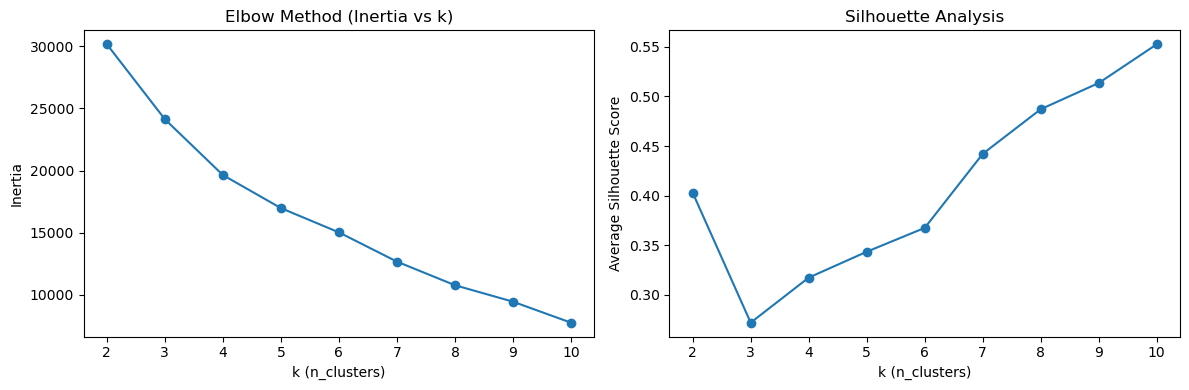

In [150]:
def kmeans_analysis_and_fit(
    X,
    k_range=range(2, 11),
    random_state=42,
    plot=True,
    visualize_2d=True,
    pca_2d_components=2
):

    X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
    inertias = []
    sil_scores = []
    ks = list(k_range)

    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_arr)
        inertias.append(km.inertia_)
        try:
            sil = silhouette_score(X_arr, labels)
        except Exception:
            sil = np.nan
        sil_scores.append(sil)

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(ks, inertias, marker='o')
        axs[0].set_xlabel('k (n_clusters)')
        axs[0].set_ylabel('Inertia')
        axs[0].set_title('Elbow Method (Inertia vs k)')
        axs[1].plot(ks, sil_scores, marker='o')
        axs[1].set_xlabel('k (n_clusters)')
        axs[1].set_ylabel('Average Silhouette Score')
        axs[1].set_title('Silhouette Analysis')
        plt.tight_layout()
        plt.show()

    def fit_k(k):
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = model.fit_predict(X_arr)
        result = {'model': model, 'labels': labels}
        if visualize_2d:
            pca = PCA(n_components=min(pca_2d_components, X_arr.shape[1]))
            coords = pca.fit_transform(X_arr)
            result['pca_2d'] = coords

            plt.figure(figsize=(6,5))
            scatter = plt.scatter(coords[:,0], coords[:,1], c=labels, s=25, cmap='tab10', alpha=0.8)
            plt.title(f'KMeans clusters (k={k}) — PCA 2D view')
            plt.xlabel('PC1'); plt.ylabel('PC2')
            plt.colorbar(scatter, label='cluster')
            plt.tight_layout()
            plt.show()
        return result

    return {
        'labels': labels,
        'k_values': ks,
        'inertias': inertias,
        'silhouette_scores': sil_scores,
        'fit_k': fit_k
    }
    print(f"{name} fitted")
    
kmeans_result = kmeans_analysis_and_fit(prepared_data.get('X'))
models = {'k_means' : kmeans_result.get('model')}
kmeans_labels = kmeans_result.get('labels')

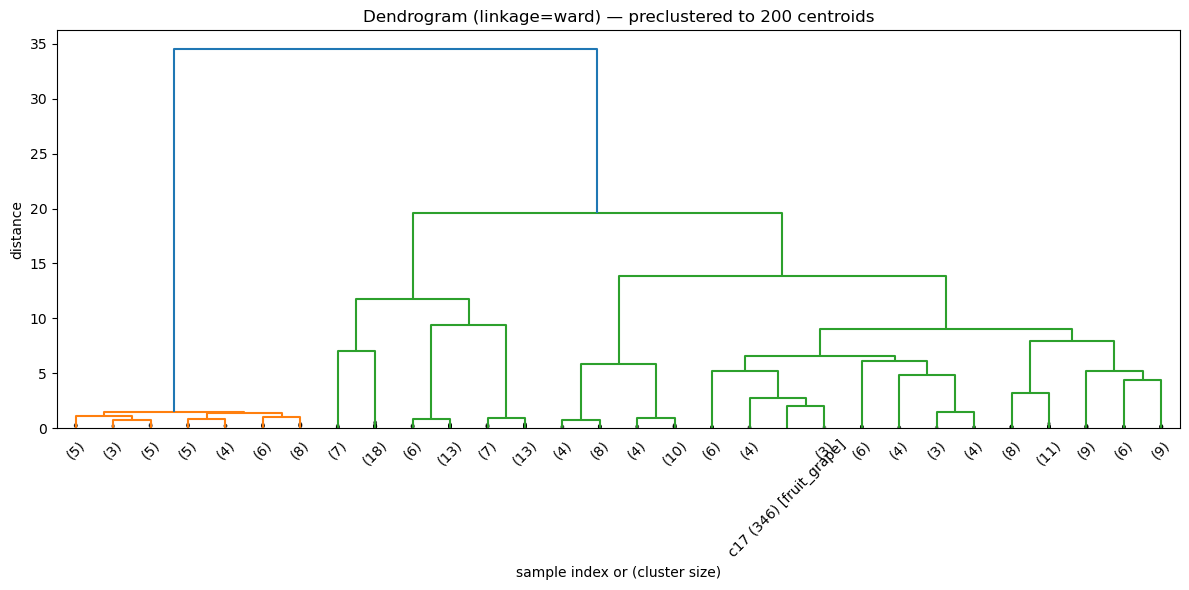

In [151]:
def agglomerative_with_readable_dendrogram(
    prepared_data: dict,
    linkage_method: str = 'ward',
    p: int = 30,
    pca_components: int | None = None,
    precluster_threshold: int = 1000,
    precluster_n: int = 200,
    sample_size: int | None = None,
    random_state: int = 0,
    show_leaf_counts: bool = True,
    color_threshold: float | None = None,
    figsize: tuple = (12,6),
    n_clusters: int | None = None,
    return_model: bool = True
) -> dict:
    
    X = prepared_data.get('X')
    if X is None:
        raise ValueError("prepared_data должен содержать ключ 'X' (DataFrame или ndarray).")
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    n_samples = X_arr.shape[0]
    labels_true = prepared_data.get('labels', None)

    X_proc = X_arr
    if pca_components is not None:
        n_pc = min(pca_components, X_arr.shape[1], X_arr.shape[0])
        if n_pc >= 1:
            pca = PCA(n_components=n_pc, random_state=random_state)
            X_proc = pca.fit_transform(X_arr)

    if sample_size is not None and sample_size < n_samples:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n_samples, size=sample_size, replace=False)
        X_proc = X_proc[idx]

    used_precluster = False
    labels_pre = None
    centroid_counts = None
    centroid_names = None
    X_for_linkage = X_proc

    if X_proc.shape[0] > precluster_threshold:
        used_precluster = True
        k_pre = min(precluster_n, max(2, X_proc.shape[0] // 2))
        kmeans = KMeans(n_clusters=k_pre, random_state=random_state, n_init=10)
        labels_pre = kmeans.fit_predict(X_proc)
        centroids = kmeans.cluster_centers_
        centroid_counts = np.bincount(labels_pre, minlength=centroids.shape[0])
        if labels_true is not None and used_precluster:

            if hasattr(labels_true, 'values') and labels_true.shape[1] >= 1 and all(c.startswith('fruit_') for c in labels_true.columns):
                arr = labels_true.values
                idx_max = np.argmax(arr, axis=1)
                has_any = arr.sum(axis=1) > 0
                true_label_simple = np.array([labels_true.columns[i] if has_any[j] else None
                                              for j,i in enumerate(idx_max)])
            elif hasattr(labels_true, 'values') and labels_true.shape[1] == 1:
                true_label_simple = labels_true.iloc[:,0].astype(str).values
            else:
                true_label_simple = labels_true.astype(str).agg('|'.join, axis=1).values

            if sample_size is not None and sample_size < n_samples:
                pass

            dom_labels = []
            for c in range(len(centroid_counts)):
                members = np.where(labels_pre == c)[0]
                if members.size == 0:
                    dom_labels.append(None)
                else:
                    vals = true_label_simple[members]
                    vals = [v for v in vals if v is not None and v != 'nan']
                    if not vals:
                        dom_labels.append(None)
                    else:
                        uniq, counts = np.unique(vals, return_counts=True)
                        dom_labels.append(uniq[np.argmax(counts)])
            if show_leaf_counts:
                centroid_names = [f"c{idx} ({cnt})" + (f" [{dom}]" if dom is not None else "") for idx, (cnt, dom) in enumerate(zip(centroid_counts, dom_labels))]
            else:
                centroid_names = [f"c{idx}" + (f" [{dom}]" if dom is not None else "") for idx, dom in enumerate(dom_labels)]
        else:
            if show_leaf_counts:
                centroid_names = [f"c{idx} ({cnt})" for idx, cnt in enumerate(centroid_counts)]
            else:
                centroid_names = [f"c{idx}" for idx in range(len(centroid_counts))]

        X_for_linkage = centroids

    Z = linkage(X_for_linkage, method=linkage_method, metric='euclidean')

    plt.figure(figsize=figsize)
    dendro_kwargs = dict(truncate_mode='lastp', p=min(p, X_for_linkage.shape[0]),
                         leaf_rotation=45, leaf_font_size=10, show_contracted=True)
    if centroid_names is not None:
        dendro_kwargs['labels'] = centroid_names

    dn = dendrogram(Z, **dendro_kwargs)
    plt.xlabel('sample index or (cluster size)')
    plt.ylabel('distance')
    title = f'Dendrogram (linkage={linkage_method})'
    if used_precluster:
        title += f' — preclustered to {len(centroid_names)} centroids'
    plt.title(title)
    if color_threshold is not None:
        plt.axhline(y=color_threshold, color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

    result = {
        'Z': Z,
        'used_precluster': used_precluster,
        'labels_preclusters': labels_pre,
        'centroid_counts': centroid_counts,
        'leaf_labels': centroid_names
    }

    if n_clusters is not None:
        agg = AgglomerativeClustering(n_clusters=int(n_clusters), linkage=linkage_method)
        labels_full = agg.fit_predict(X_arr)

        result['_fitted_model'] = agg
        result['labels'] = labels_full

        result['model'] = agg if return_model else None

    return result


res2 = agglomerative_with_readable_dendrogram(prepared_data, n_clusters=4)
agglomerative_labels = res2['labels']
models['agglomerative'] = res2['model']


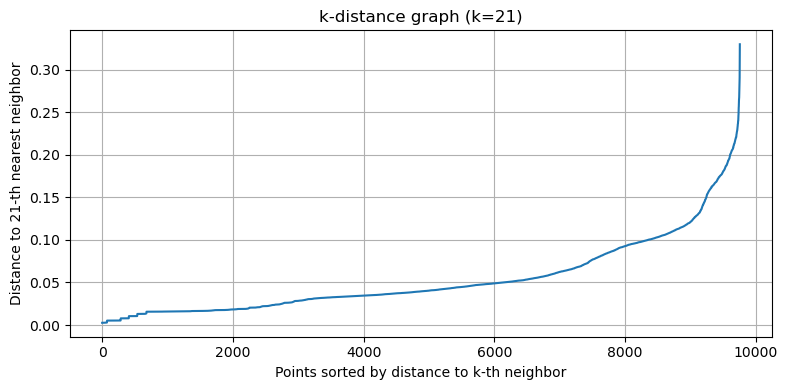

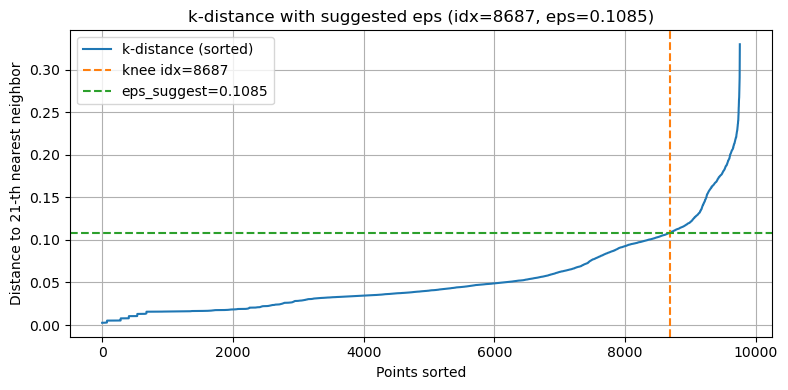

DBSCAN finished: eps=0.108512, min_samples=21
Clusters (excluding noise): 19; cluster_counts (label:count): {-1: 528, 0: 516, 1: 488, 2: 502, 3: 534, 4: 346, 5: 489, 6: 481, 7: 443, 8: 495, 9: 462, 10: 500, 11: 534, 12: 531, 13: 495, 14: 492, 15: 484, 16: 496, 17: 506, 18: 432}
Silhouette (excluding noise): 0.8869483993294673


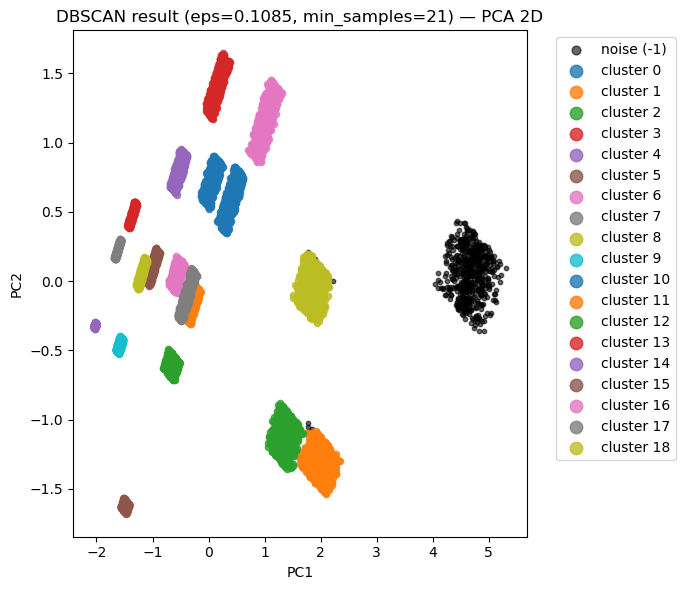

In [152]:
def dbscan_pipeline_from_prepared(
    prepared_data,
    min_samples: int | None = None,
    plot_k_distance: bool = True,
    auto_estimate_eps: bool = True,
    eps: float | None = None,
    run_dbscan: bool = True,
    visualize: bool = True,
    pca_components: int = 2,
    random_state: int = 0
) -> dict:
    
    X = prepared_data.get('X')
    if X is None:
        raise ValueError("prepared_data must contain 'X' (DataFrame or ndarray).")
    X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
    n_samples, n_features = X_arr.shape

    if min_samples is None:
        min_samples = max(4, n_features + 1)

    k = max(1, int(min_samples))
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_arr)
    distances, _ = nbrs.kneighbors(X_arr)
    k_dist = np.sort(distances[:, -1])

    result = {
        'X': X_arr,
        'min_samples': min_samples,
        'k_distances': k_dist,
        'eps_suggestion': None,
        'eps_used': None,
        '_fitted_model': None,
        'dbscan_model': None,
        'labels': np.array([], dtype=int),
        'ran_dbscan': False,
        'n_clusters': None,
        'cluster_counts': None,
        'silhouette_excluding_noise': None,
        'pca_2d': None
    }

    if plot_k_distance:
        plt.figure(figsize=(8,4))
        plt.plot(k_dist)
        plt.xlabel('Points sorted by distance to k-th neighbor')
        plt.ylabel(f'Distance to {k}-th nearest neighbor')
        plt.title(f'k-distance graph (k={k})')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def estimate_eps_by_farthest_point(y_sorted):
        n = len(y_sorted)
        if n < 3:
            return 0, float(y_sorted[-1]) if n>0 else 0.0
        x = np.arange(n).astype(float)
        x1, y1 = x[0], y_sorted[0]
        x2, y2 = x[-1], y_sorted[-1]
        Lx = x2 - x1
        Ly = y2 - y1
        num = np.abs(Ly * x - Lx * y_sorted + x2*y1 - y2*x1)
        den = np.sqrt(Lx**2 + Ly**2)
        d = num / (den + 1e-12)
        idx = int(np.argmax(d))
        return idx, float(y_sorted[idx])

    if auto_estimate_eps and eps is None:
        idx_knee, eps_suggest = estimate_eps_by_farthest_point(k_dist)
        result['eps_suggestion'] = eps_suggest

        plt.figure(figsize=(8,4))
        plt.plot(k_dist, label='k-distance (sorted)')
        plt.axvline(x=idx_knee, color='C1', linestyle='--', label=f'knee idx={idx_knee}')
        plt.axhline(y=eps_suggest, color='C2', linestyle='--', label=f'eps_suggest={eps_suggest:.4g}')
        plt.xlabel('Points sorted')
        plt.ylabel(f'Distance to {k}-th nearest neighbor')
        plt.title(f'k-distance with suggested eps (idx={idx_knee}, eps={eps_suggest:.4g})')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    eps_used = eps if eps is not None else result['eps_suggestion']
    result['eps_used'] = eps_used

    if run_dbscan:
        if eps_used is None:
            print("EPS is not provided and auto estimation disabled or failed. DBSCAN not run. Provide eps or enable auto_estimate_eps.")
            return result

        model = DBSCAN(eps=float(eps_used), min_samples=int(min_samples), metric='euclidean')
        labels = model.fit_predict(X_arr)

        result['_fitted_model'] = model
        result['dbscan_model'] = model
        result['labels'] = np.asarray(labels)
        result['ran_dbscan'] = True

        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = dict(zip([int(u) for u in unique.tolist()], counts.tolist()))
        result['cluster_counts'] = cluster_counts

        n_clusters = len([u for u in unique if u != -1])
        result['n_clusters'] = n_clusters

        try:
            mask = labels != -1
            if mask.sum() >= 2 and len(np.unique(labels[mask])) >= 2:
                sil = silhouette_score(X_arr[mask], labels[mask])
            else:
                sil = np.nan
        except Exception:
            sil = np.nan
        result['silhouette_excluding_noise'] = sil

        print(f"DBSCAN finished: eps={eps_used:.6g}, min_samples={min_samples}")
        print(f"Clusters (excluding noise): {n_clusters}; cluster_counts (label:count): {cluster_counts}")
        print(f"Silhouette (excluding noise): {sil}")

        if visualize:
            pca_n = min(pca_components, X_arr.shape[1])
            if pca_n >= 1:
                pca = PCA(n_components=pca_n, random_state=random_state)
                coords = pca.fit_transform(X_arr)
                if coords.shape[1] >= 2:
                    plt.figure(figsize=(7,6))
                    labels_unique = np.unique(labels)
                    for lab in labels_unique:
                        mask_lab = labels == lab
                        if lab == -1:
                            plt.scatter(coords[mask_lab,0], coords[mask_lab,1], c='k', s=10, alpha=0.6, label='noise (-1)')
                        else:
                            plt.scatter(coords[mask_lab,0], coords[mask_lab,1], s=20, alpha=0.8, label=f'cluster {lab}')
                    plt.title(f'DBSCAN result (eps={eps_used:.4g}, min_samples={min_samples}) — PCA 2D')
                    plt.xlabel('PC1'); plt.ylabel('PC2')
                    plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
                    plt.tight_layout()
                    plt.show()
                else:
                    plt.figure(figsize=(8,3))
                    for lab in np.unique(labels):
                        mask_lab = labels == lab
                        xvals = coords[mask_lab,0]
                        y = np.zeros_like(xvals) + (lab if lab!=-1 else -1)
                        plt.scatter(xvals, y, s=12, alpha=0.7, label=f"{'noise' if lab==-1 else 'cluster '+str(lab)}")
                    plt.yticks([])
                    plt.xlabel('PC1')
                    plt.title(f'DBSCAN result (eps={eps_used:.4g}, min_samples={min_samples}) — PCA 1D')
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
                result['pca_2d'] = coords
            else:
                result['pca_2d'] = None

    return result


res = dbscan_pipeline_from_prepared(prepared_data, min_samples=None, plot_k_distance=True, auto_estimate_eps=True)
models['dbscan'] = res.get('dbscan_model')
dbscan_labels = res.get('labels')

## 4.Оценка результатов моделей

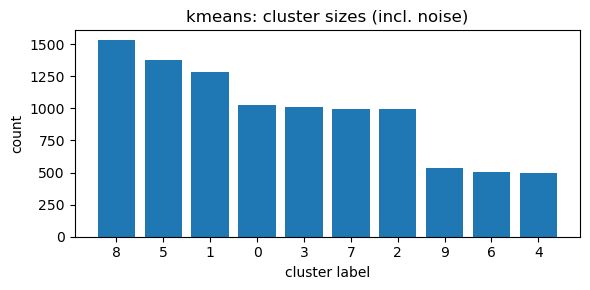

/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showflier

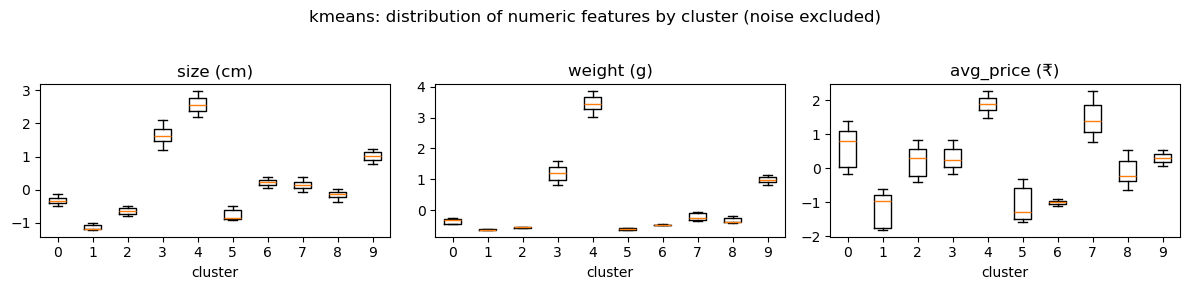

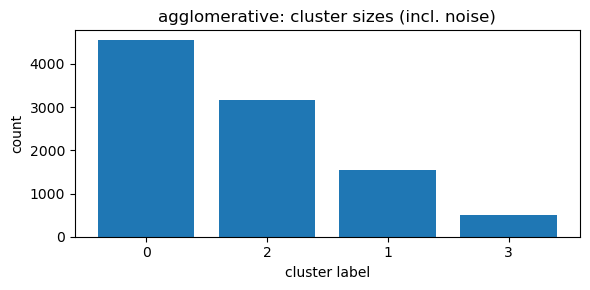

/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showflier

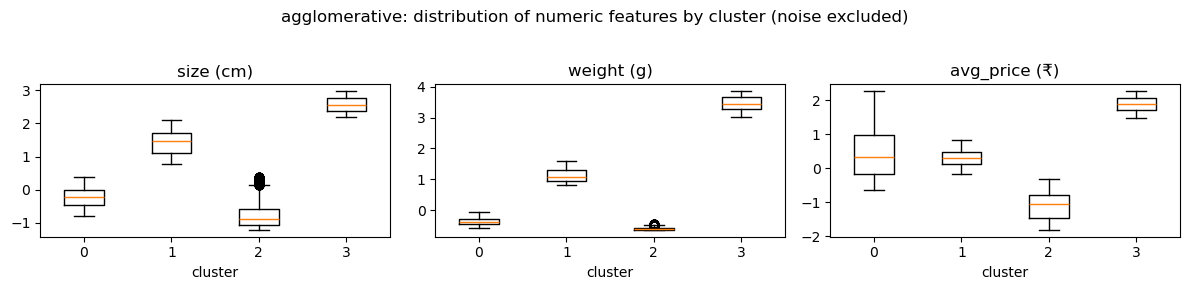

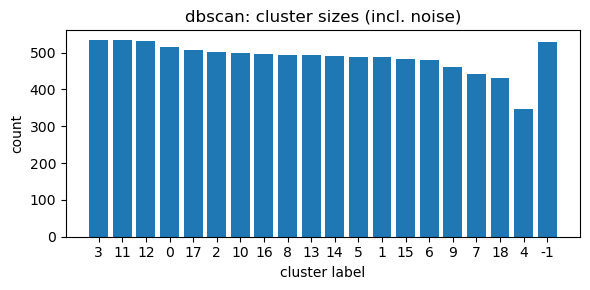

/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
/var/folders/rh/tb6ld7ws7b7gz_10xsscc0g00000gn/T/ipykernel_25745/2591338306.py:232: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showflier

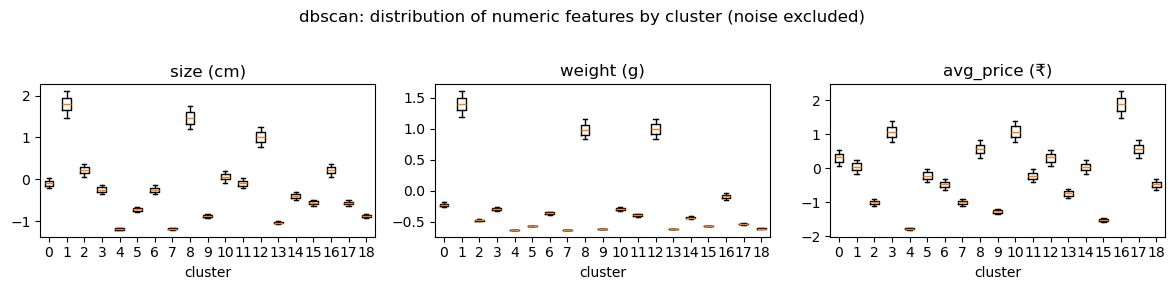

               n_samples  n_noise  pct_noise  n_clusters_excl_noise  \
model                                                                 
kmeans              9754        0   0.000000                     10   
agglomerative       9754        0   0.000000                      4   
dbscan              9754      528   0.054132                     19   

               silhouette  davies_bouldin  calinski_harabasz       ARI  \
model                                                                    
kmeans           0.329557        1.275594       16698.795497  0.588207   
agglomerative    0.506526        0.593438       17229.654187  0.178830   
dbscan           0.586768        0.597809       39613.690500  1.000000   

                    NMI  
model                    
kmeans         0.855232  
agglomerative  0.560391  
dbscan         1.000000  


In [153]:
import math


def _get_true_labels_array(labels_df):
    if labels_df is None:
        return None
    if isinstance(labels_df, pd.Series):
        return labels_df.astype(object).where(labels_df.notna(), None).values
    if isinstance(labels_df, pd.DataFrame):
        cols = list(labels_df.columns)
        if all(str(c).startswith('fruit_') for c in cols):
            arr = labels_df.values
            idx = np.argmax(arr, axis=1)
            has_any = arr.sum(axis=1) > 0
            names = [c[len('fruit_'):] if c.startswith('fruit_') else c for c in cols]
            out = np.array([names[idx[i]] if has_any[i] else None for i in range(len(idx))], dtype=object)
            return out
        if labels_df.shape[1] == 1:
            return labels_df.iloc[:,0].astype(object).where(labels_df.iloc[:,0].notna(), None).values
        return labels_df.astype(str).agg('|'.join, axis=1).where(labels_df.notna().any(axis=1), None).values
    arr = np.asarray(labels_df)
    if arr.ndim == 1:
        return arr.astype(object)
    return np.array(['|'.join(map(str,row)) for row in arr], dtype=object)


def evaluate_models_with_boxplots(
    prepared_data: dict,
    model_labels: dict,
    numeric_cols: list | None = None,
    noise_label: int = -1,
    exclude_noise_from_plots: bool = True,
    figsize_per_model: tuple = (14, 6),
    boxplot_cols_per_row: int = 3,
    show_cluster_size_bar: bool = True
) -> dict:
    
    X = prepared_data.get('X')
    if X is None:
        raise ValueError("prepared_data must contain key 'X' (DataFrame or ndarray).")
    if numeric_cols is None:
        if prepared_data.get('X_num') is not None:
            X_num_df = prepared_data['X_num'].copy()
            numeric_cols = list(X_num_df.columns)
        else:
            if hasattr(X, 'select_dtypes'):
                numeric_cols = list(X.select_dtypes(include=[np.number]).columns)
            else:
                raise ValueError("Cannot infer numeric columns: provide numeric_cols or prepared_data['X_num'].")
    else:
        numeric_cols = [c for c in numeric_cols if c in X.columns]
    if not numeric_cols:
        raise ValueError("No numeric columns found for boxplots.")

    X_df = X.copy() if hasattr(X, 'copy') else pd.DataFrame(X, columns=[f'c{i}' for i in range(X.shape[1])])
    n_samples = X_df.shape[0]

    true_labels = _get_true_labels_array(prepared_data.get('labels', None))

    metrics_rows = []
    per_model = {}

    for model_name, labels in model_labels.items():
        labels = np.asarray(labels)
        if labels.size == 0:

            metrics_rows.append({
                'model': model_name,
                'n_samples': n_samples,
                'n_noise': np.nan,
                'pct_noise': np.nan,
                'n_clusters_excl_noise': np.nan,
                'silhouette': np.nan,
                'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan,
                'ARI': np.nan,
                'NMI': np.nan
            })
            per_model[model_name] = {'labels': labels, 'cluster_counts': {}, 'n_noise': None}
            continue

        if labels.shape[0] != n_samples:
            raise ValueError(f"labels for model '{model_name}' length != n_samples.")

        mask_noise = (labels == noise_label)
        n_noise = int(np.sum(mask_noise))
        pct_noise = n_noise / n_samples

        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = dict(zip([int(u) for u in unique.tolist()], counts.tolist()))

        mask_keep = ~mask_noise
        X_keep = X_df.loc[mask_keep, numeric_cols].values
        labels_keep = labels[mask_keep]

        sil = db = ch = np.nan
        if X_keep.shape[0] >= 2 and len(np.unique(labels_keep)) >= 2:
            try:
                sil = float(silhouette_score(X_keep, labels_keep))
            except Exception:
                sil = np.nan
            try:
                db = float(davies_bouldin_score(X_keep, labels_keep))
            except Exception:
                db = np.nan
            try:
                ch = float(calinski_harabasz_score(X_keep, labels_keep))
            except Exception:
                ch = np.nan

        ARI = NMI = np.nan
        if true_labels is not None:
            true_keep = true_labels[mask_keep]

            if X_keep.shape[0] >= 2 and len(np.unique(labels_keep)) >= 2 and len(np.unique(true_keep)) >= 2:
                try:
                    ARI = float(adjusted_rand_score(true_keep, labels_keep))
                except Exception:
                    ARI = np.nan
                try:
                    NMI = float(normalized_mutual_info_score(true_keep, labels_keep))
                except Exception:
                    NMI = np.nan

        metrics_rows.append({
            'model': model_name,
            'n_samples': n_samples,
            'n_noise': n_noise,
            'pct_noise': pct_noise,
            'n_clusters_excl_noise': len([u for u in np.unique(labels_keep) if u != noise_label]),
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch,
            'ARI': ARI,
            'NMI': NMI
        })

        per_model[model_name] = {
            'labels': labels,
            'cluster_counts': cluster_counts,
            'n_noise': n_noise,
            'pct_noise': pct_noise
        }

        if show_cluster_size_bar:
            fig = plt.figure(figsize=(6,3))
            items = sorted(cluster_counts.items(), key=lambda x: (x[0]==noise_label, -x[1]))
            labs = [str(k) for k,_ in items]
            vals = [v for _,v in items]
            plt.bar(labs, vals)
            plt.title(f"{model_name}: cluster sizes (incl. noise)")
            plt.xlabel("cluster label")
            plt.ylabel("count")
            plt.tight_layout()
            plt.show()

        df_plot = X_df.copy()
        df_plot['__cluster__'] = labels
        if exclude_noise_from_plots and (noise_label in df_plot['__cluster__'].values):
            df_plot = df_plot[df_plot['__cluster__'] != noise_label]
            if df_plot.empty:
                print(f"[{model_name}] No non-noise points to plot boxplots.")
                continue

        n_feats = len(numeric_cols)
        cols = boxplot_cols_per_row
        rows = math.ceil(n_feats / cols)
        if figsize_per_model is None:
            figsize_per_model = (12, 4)

            fig, axes = plt.subplots(rows, cols, figsize=figsize_per_model, sharey=False)
        fig_height = 3 * rows
        fig_width = 4 * min(n_feats, cols)
        fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))
        axes = np.array(axes).reshape(-1)

        for i, feat in enumerate(numeric_cols):
            ax = axes[i]
            labels_order = sorted(df_plot['__cluster__'].unique())
            data_to_plot = [df_plot.loc[df_plot['__cluster__'] == lab, feat].dropna().values for lab in labels_order]
            if all(len(x)==0 for x in data_to_plot):
                ax.text(0.5, 0.5, f'no data for {feat}', ha='center', va='center')
            else:
                ax.boxplot(data_to_plot, labels=[str(l) for l in labels_order], showfliers=True)
            ax.set_title(feat)
            ax.set_xlabel('cluster')
        for j in range(n_feats, rows*cols):
            axes[j].axis('off')
        plt.suptitle(f"{model_name}: distribution of numeric features by cluster ({'noise excluded' if exclude_noise_from_plots else 'noise included'})")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    metrics_df = pd.DataFrame(metrics_rows).set_index('model')
    col_order = ['n_samples','n_noise','pct_noise','n_clusters_excl_noise',
                 'silhouette','davies_bouldin','calinski_harabasz','ARI','NMI']
    metrics_df = metrics_df[[c for c in col_order if c in metrics_df.columns]]

    return {
        'metrics_df': metrics_df,
        'per_model': per_model
    }

prepared_data = prepare_dataset_for_clustering(dataset)
model_labels = {
    'kmeans': kmeans_labels,
    'agglomerative': agglomerative_labels,
    'dbscan': dbscan_labels
}
out = evaluate_models_with_boxplots(prepared_data, model_labels)
print(out['metrics_df'])